### Generating Overfit Models

By default, you scikitlearn tree models will grow until every node is pure.  To explore this, you are to build different models using the `max_depth` parameter and determine when the tree begins to overfit the data.  For depths from `max_depth = 1` until the tree is completed, keep track of the accuracy on training vs. test data and generate a plot with depths as the horizontal axis and accuracy as the vertical axis for train and test data.  

Repeat this process with different splits of the data to determine at what depth the tree begins to overfit.  Share your results with your peers and discuss your approach to generating the visualization.  What are the consequences of this overfitting for your approach to building Decision Trees?   We provide a small dataset with health data where your goal is to predict whether or not the individuals survive.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


In [24]:
data = pd.read_csv('data/Whickham.txt')

In [25]:
data.head()

,outcome,smoker,age
0,Alive,Yes,23
1,Alive,Yes,18
2,Dead,Yes,71
3,Alive,No,67
4,Alive,No,64


In [26]:
X = data[['smoker', 'age']]
X['smoker'] = X['smoker'].map({'Yes':1, 'No': 0})
y = data['outcome'].map({'Dead': 1, 'Alive': 0})

/var/folders/fc/hjn_jg6d2w73x14dw03ws6c40000gn/T/ipykernel_2761/1977429350.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['smoker'] = X['smoker'].map({'Yes':1, 'No': 0})


### Calculate the accuracy of a Decision Tree Classifier for different `max_depth` values and plot the results.

In [27]:

def track_and_plot_accuracy(models, X_train, y_train, X_test, y_test):
    """
    Calculates training and test accuracy for a list of trained models and
    plots the results against their max_depth values.

    Parameters:
    - models (list): A list of trained scikit-learn DecisionTreeClassifier instances.
    - X_train (DataFrame/array-like): Training features.
    - y_train (Series/array-like): Training target.
    - X_test (DataFrame/array-like): Test features.
    - y_test (Series/array-like): Test target.

    Returns:
    - tuple: (depths, train_accuracies, test_accuracies)
    """
    depths = [model.get_depth() for model in models]
    # In case user wants to plot by max_depth parameter explicitly set
    # but the tree might be shallower if it reaches purity early.
    # However, the prompt says "depths as the horizontal axis".
    # Let's use the actual max_depth if provided, otherwise the model depth.
    max_depth_params = [model.max_depth if model.max_depth is not None else model.get_depth() for model in models]

    train_accs = [accuracy_score(y_train, model.predict(X_train)) for model in models]
    test_accs = [accuracy_score(y_test, model.predict(X_test)) for model in models]

    plt.figure(figsize=(10, 6))
    plt.plot(max_depth_params, train_accs, label='Train Accuracy', marker='o')
    plt.plot(max_depth_params, test_accs, label='Test Accuracy', marker='o')
    plt.xlabel('Tree Depth (max_depth)')
    plt.ylabel('Accuracy')
    plt.title('Decision Tree Accuracy vs. Depth')
    plt.legend()
    plt.grid(True)
    plt.show()

    return max_depth_params, train_accs, test_accs

## Data preparation

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((1051, 2), (263, 2))

In [35]:
depth = [i for i in range(1,15)]


In [36]:
models = []
for d in depth:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    models.append(model)


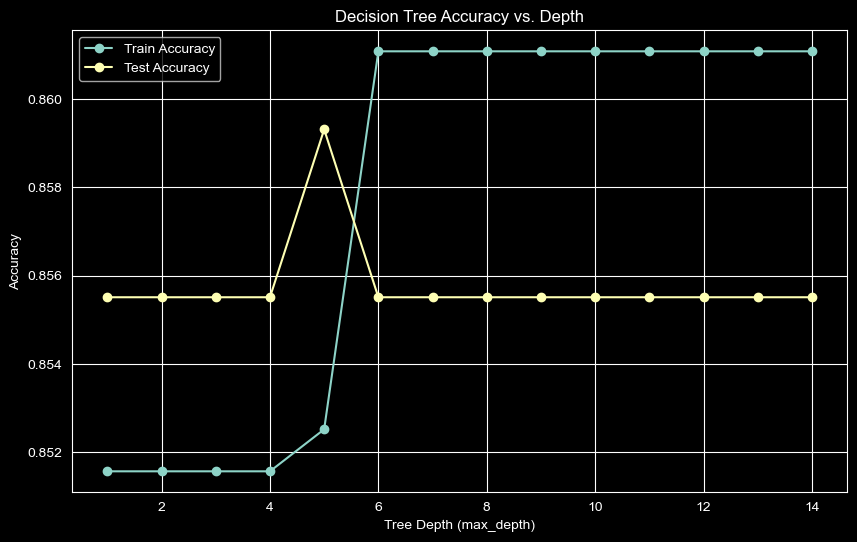

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [0.851569933396765,
  0.851569933396765,
  0.851569933396765,
  0.851569933396765,
  0.8525214081826832,
  0.8610846812559467,
  0.8610846812559467,
  0.8610846812559467,
  0.8610846812559467,
  0.8610846812559467,
  0.8610846812559467,
  0.8610846812559467,
  0.8610846812559467,
  0.8610846812559467],
 [0.8555133079847909,
  0.8555133079847909,
  0.8555133079847909,
  0.8555133079847909,
  0.8593155893536122,
  0.8555133079847909,
  0.8555133079847909,
  0.8555133079847909,
  0.8555133079847909,
  0.8555133079847909,
  0.8555133079847909,
  0.8555133079847909,
  0.8555133079847909,
  0.8555133079847909])

In [37]:
track_and_plot_accuracy(models, X_train, y_train,X_test, y_test)

***Interpretation:***

Models seems to start overfitting around depth 6, where the training accuracy is >90% but test accuracy drops significantly compare to previous depths.  This suggests that the best depth is around 5, where the test accuracy increase to 86%.  This is a common trade-off in model complexity and generalization, where increasing depth can improve training performance but may lead to overfitting.  It's important to balance model complexity with generalization performance to achieve optimal results.